1. **Title**

Day 18 & 19 - Student Performance Prediction and Model Evaluation

This notebook follows a complete machine learning workflow to analyze and predict
student exam performance. It includes EDA, data preprocessing, Linear Regression,
classification, model evaluation, and analysis of overfitting and underfitting.

2. **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

3. **Load Dataset**

In [2]:
df = pd.read_csv("Day18_19_student_habits_performance.csv")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


4. **Dataset Overview**

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 16


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


5. **Check Missing Values**

In [6]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


6. **Check Numerical and Categorical Variables**





In [7]:
numerical_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numerical Variables:")
print(numerical_columns)

print("\nCategorical Variables:")
print(categorical_columns)

Numerical Variables:
Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

Categorical Variables:
Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')


7. **EDA — Exam Score Distribution**

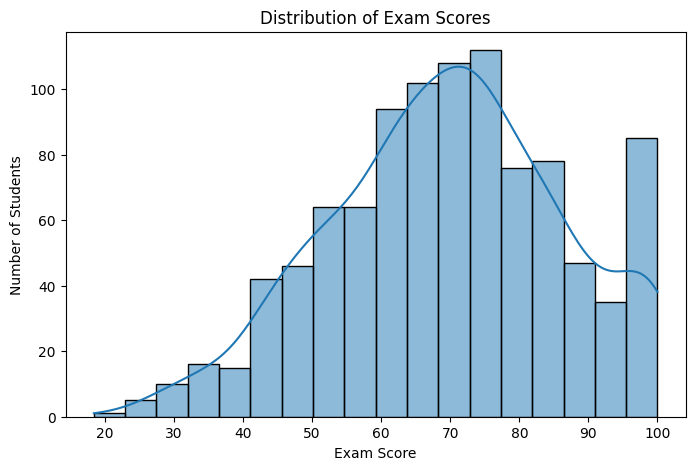

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df["exam_score"], kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The distribution shows how exam scores are spread across the students and gives an overall idea of the typical performance in the dataset.

8. **Study Hours vs Exam Score**

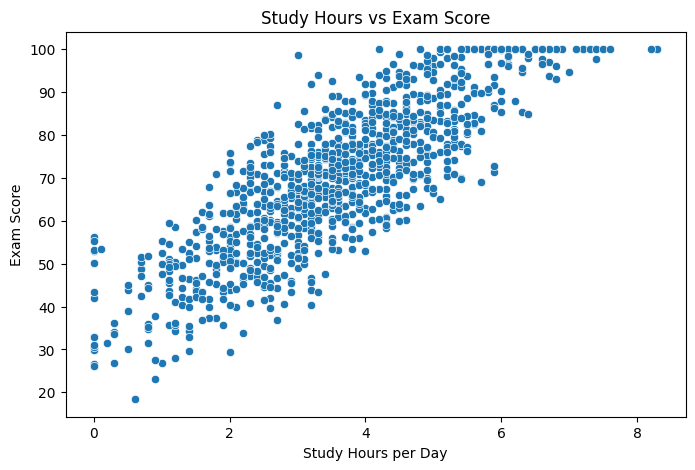

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="study_hours_per_day",
    y="exam_score"
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")

plt.show()

### Interpretation

The plot shows a positive relationship between study hours and exam scores. Students who spend more time studying generally tend to achieve higher scores.

9. **Attendance vs Exam Score**

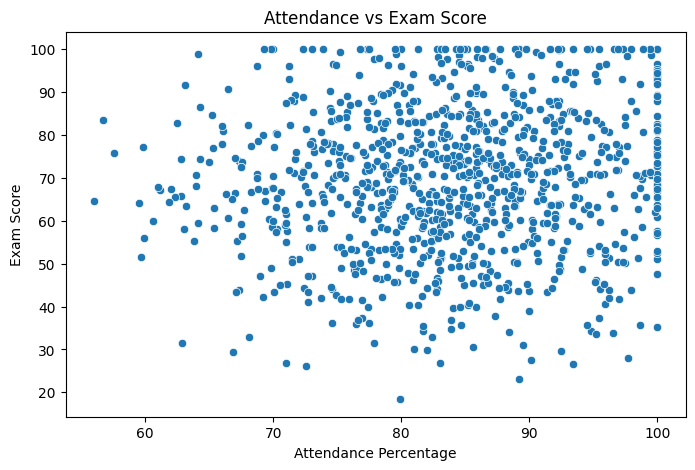

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="exam_score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Score")

plt.show()

10. **Sleep vs Exam Score**

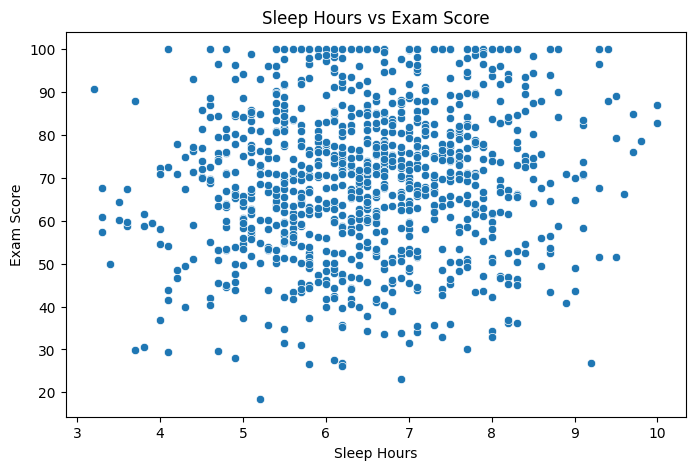

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sleep_hours",
    y="exam_score"
)

plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")

plt.show()

11. **Correlation Analysis**

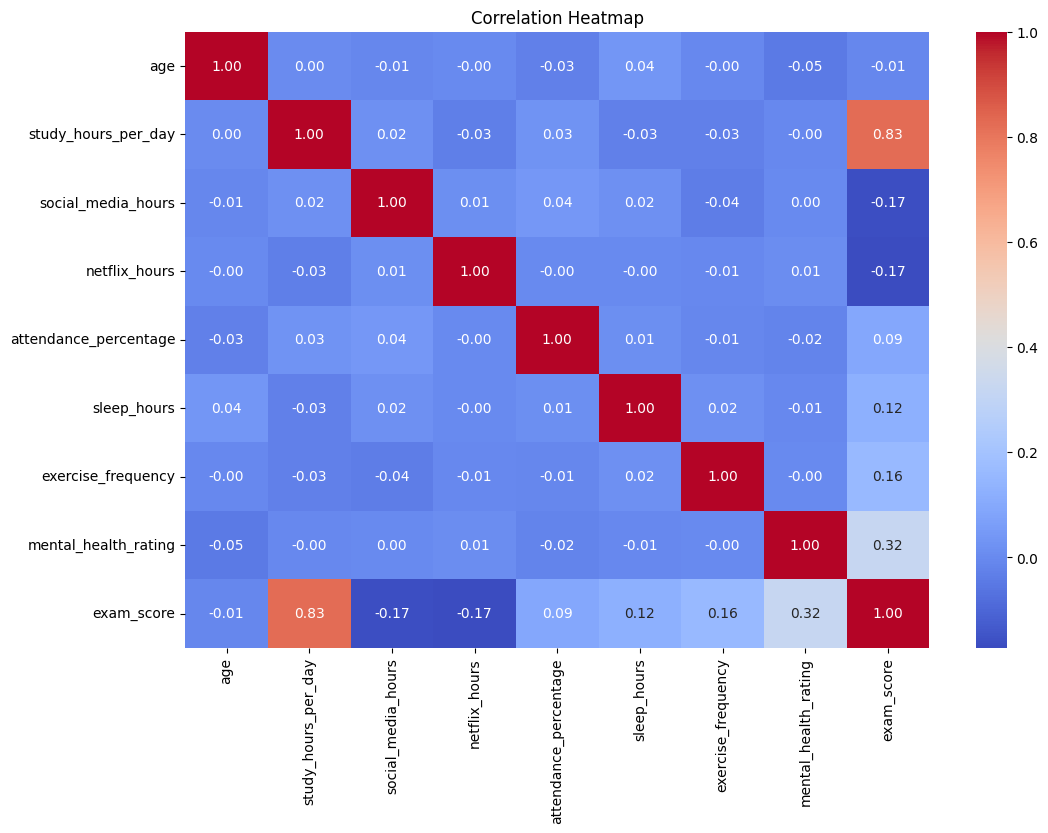

In [12]:
correlation = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [13]:
correlation["exam_score"].sort_values(ascending=False)

,exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


12. **EDA — Categorical Variables**

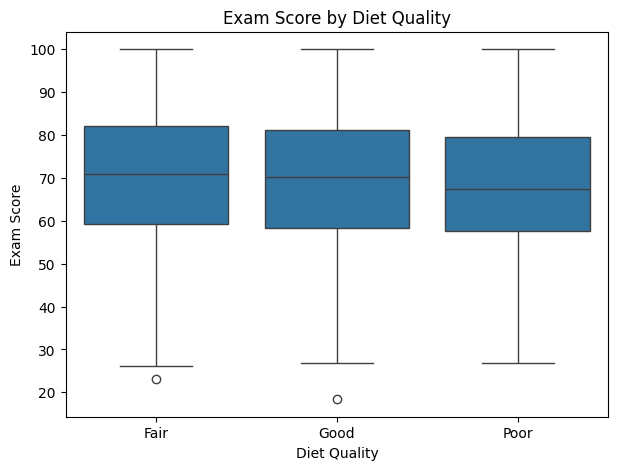

In [14]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="diet_quality",
    y="exam_score"
)

plt.title("Exam Score by Diet Quality")
plt.xlabel("Diet Quality")
plt.ylabel("Exam Score")

plt.show()

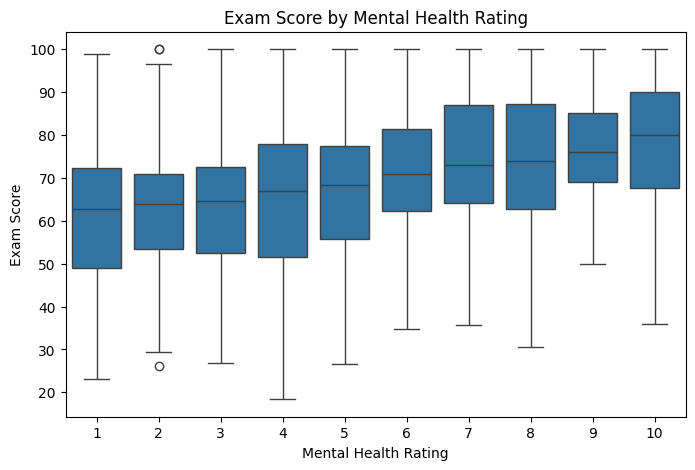

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="mental_health_rating",
    y="exam_score"
)

plt.title("Exam Score by Mental Health Rating")
plt.xlabel("Mental Health Rating")
plt.ylabel("Exam Score")

plt.show()

13. **Prepare Features and Target**

In [17]:
X = df.drop(["exam_score", "student_id"], axis=1)
y = df["exam_score"]

14. **Train-Test Split**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [ ]:
print("Cancellation Rate:",
      round(df["Is_Canceled"].mean() * 100, 2), "%")

Cancellation Rate: 72.18 %


15. **Identify Feature Types**

In [19]:
numeric_features = X.select_dtypes(include="number").columns
categorical_features = X.select_dtypes(include="object").columns

print("Numeric:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numeric: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


16. **Preprocessing**

In [20]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

17. **Linear Regression Model**

In [21]:
regression_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

regression_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))])),
                ('model', LinearRegression())])

18. **Generate Predictions**

In [22]:
y_pred = regression_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[66.20077804 75.12000136 78.05849507 73.33465453 61.01915606 54.05845019
 75.57324219 55.04257761 40.67372532 72.41772902]


19. **Regression Evaluation**

In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.192343110379915
MSE: 26.532535044099482
RMSE: 5.150974183986897
R² Score: 0.8965307156715965


### Regression Evaluation

MAE shows the average absolute prediction error.

RMSE gives more importance to larger prediction errors.

R² shows how much of the variation in exam scores is explained by the model. A higher R² indicates better explanatory performance.

20. **Actual vs Predicted Scores**

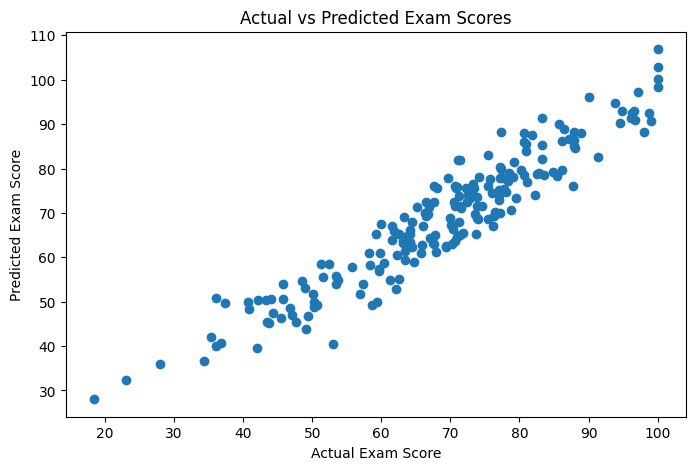

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

21. **Training vs Testing Performance**

In [25]:
train_r2 = regression_model.score(X_train, y_train)
test_r2 = regression_model.score(X_test, y_test)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.9021075354141658
Testing R²: 0.8965307156715965


### Interpretation

The training and testing R² scores can be compared to check whether the model generalizes well. A very large difference between the two scores may indicate overfitting, while low scores on both sets may indicate underfitting.

22. **Create Classification Target**

In [26]:
df["result"] = np.where(
    df["exam_score"] >= 50,
    "Pass",
    "Fail"
)

df["result"].value_counts()

,count
result,
Pass,869
Fail,131


23. **Classification Features and Target**

In [27]:
X_class = df.drop(
    ["exam_score", "result", "student_id"],
    axis=1
)

y_class = df["result"]

24. **Classification Train-Test Split**



In [28]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

25. **Classification Preprocessing**

In [29]:
numeric_features_class = X_class.select_dtypes(include="number").columns
categorical_features_class = X_class.select_dtypes(include="object").columns

preprocessor_class = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features_class),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features_class)
])

26. **Train Classification Model**

In [30]:
classification_model = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", LogisticRegression(max_iter=1000))
])

classification_model.fit(
    X_train_class,
    y_train_class
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

27. **Generate Classification Predictions**

In [31]:
y_class_pred = classification_model.predict(X_test_class)
print(y_class_pred[:10])

['Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass']


28. **Classification Evaluation**

In [32]:
accuracy = accuracy_score(y_test_class, y_class_pred)
precision = precision_score(
    y_test_class,
    y_class_pred,
    pos_label="Pass"
)
recall = recall_score(
    y_test_class,
    y_class_pred,
    pos_label="Pass"
)
f1 = f1_score(
    y_test_class,
    y_class_pred,
    pos_label="Pass"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.96
Precision: 0.9770114942528736
Recall: 0.9770114942528736
F1 Score: 0.9770114942528736


29. **Confusion Matrix**

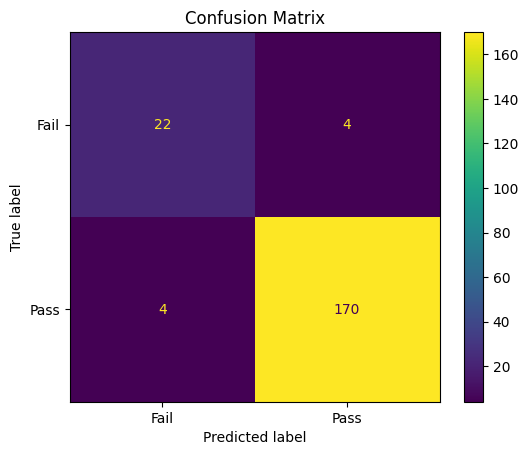

In [33]:
cm = confusion_matrix(
    y_test_class,
    y_class_pred,
    labels=["Fail", "Pass"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows how many students were correctly classified as Pass or Fail and how many were incorrectly classified.

30. **Training vs Testing Classification Accuracy**

In [34]:
train_class_accuracy = classification_model.score(
    X_train_class,
    y_train_class
)

test_class_accuracy = classification_model.score(
    X_test_class,
    y_test_class
)

print("Training Accuracy:", train_class_accuracy)
print("Testing Accuracy:", test_class_accuracy)

Training Accuracy: 0.9575
Testing Accuracy: 0.96


31. **Overfitting / Underfitting**

The training and testing scores are compared to understand how well the models generalize.

If the training score is much higher than the testing score, the model may be overfitting.

If both training and testing scores are low, the model may be underfitting.

If the training and testing scores are reasonably close, the model is likely generalizing better to unseen data.

32. **Final 5 Insights**


- Study time and attendance are important factors associated with exam performance, with students who study more and attend classes regularly generally achieving better scores.

- Sleep, social media usage, and Netflix usage provide additional information about student habits and can help explain differences in academic performance.

- The correlation analysis shows that not all student habits have the same relationship with exam scores, making it useful to consider several factors together rather than relying on a single variable.

- The regression model can estimate exam scores from a combination of academic habits, lifestyle factors, and personal characteristics rather than using study hours alone.

- Converting exam scores into Pass and Fail categories allows the classification model to identify students who are likely to meet the passing threshold and provides a different way of evaluating student performance.